# Model Evaluation

Evaluate and compare the trained LightGBM models on the held-out test set.

This phase measures model performance using classification metrics, analyzes prediction errors, compares the baseline and tuned models, and selects the best-performing model for deployment.

# Model Evaluation

Evaluate and compare the trained LightGBM models on the held-out test set.

This phase measures model performance using classification metrics, analyzes prediction errors, compares the baseline and tuned models, and selects the best-performing model for deployment.

In [12]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from dotenv import load_dotenv

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)

In [13]:
load_dotenv()

BASE_PATH = os.getenv("BASE_PATH")

if not BASE_PATH:
    raise ValueError("BASE_PATH is not set in the .env file.")

print("Evaluation setup completed.")

Evaluation setup completed.


In [14]:
X_test = pd.read_parquet(
    f"{BASE_PATH}/data/final/X_test_final.parquet"
)

y_test = pd.read_parquet(
    f"{BASE_PATH}/data/final/y_test_final.parquet"
)

y_test = y_test.iloc[:, 0]

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_test shape: (19897, 126)
y_test shape: (19897,)


## 2. Load Trained Models

Load the baseline and tuned LightGBM models produced during the Modeling phase.

In [15]:
baseline_model = joblib.load(
    f"{BASE_PATH}/models/lgbm_baseline.pkl"
)

tuned_model = joblib.load(
    f"{BASE_PATH}/models/lgbm_tuned.pkl"
)

print("Baseline model loaded successfully.")
print("Tuned model loaded successfully.")

Baseline model loaded successfully.
Tuned model loaded successfully.


## 3. Generate Predictions

Generate probability predictions from both models.

Probability predictions are used for PR-AUC and ROC-AUC, while a classification threshold is used for metrics such as precision, recall, and F1-score.

In [16]:
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]
tuned_proba = tuned_model.predict_proba(X_test)[:, 1]

print("Baseline predictions:", baseline_proba.shape)
print("Tuned predictions:", tuned_proba.shape)

Baseline predictions: (19897,)
Tuned predictions: (19897,)


## 4. Overall Model Performance

Compare the baseline and tuned models using PR-AUC and ROC-AUC.

PR-AUC is particularly useful for this problem because rainfall prediction is an imbalanced binary classification task.

In [17]:
baseline_pr_auc = average_precision_score(y_test, baseline_proba)
baseline_roc_auc = roc_auc_score(y_test, baseline_proba)

tuned_pr_auc = average_precision_score(y_test, tuned_proba)
tuned_roc_auc = roc_auc_score(y_test, tuned_proba)

performance = pd.DataFrame({
    "Model": ["Baseline", "Tuned"],
    "PR-AUC": [baseline_pr_auc, tuned_pr_auc],
    "ROC-AUC": [baseline_roc_auc, tuned_roc_auc],
})

performance

,Model,PR-AUC,ROC-AUC
0,Baseline,0.779255,0.908311
1,Tuned,0.807236,0.922616


### Performance Summary

The tuned model is compared against the baseline using the two primary ranking metrics.

A higher PR-AUC and ROC-AUC indicate better ability to distinguish between rainfall and no-rainfall cases.

## 5. Classification Report

Evaluate the models using a classification threshold of 0.5.

This provides precision, recall, F1-score, and support for both classes.

In [18]:
baseline_pred = (baseline_proba >= 0.5).astype(int)
tuned_pred = (tuned_proba >= 0.5).astype(int)

print("Baseline Classification Report")
print(
    classification_report(
        y_test,
        baseline_pred,
        target_names=["No Rain", "Rain"]
    )
)

print("\nTuned Classification Report")
print(
    classification_report(
        y_test,
        tuned_pred,
        target_names=["No Rain", "Rain"]
    )
)

Baseline Classification Report
              precision    recall  f1-score   support

     No Rain       0.94      0.81      0.87     15426
        Rain       0.56      0.84      0.67      4471

    accuracy                           0.81     19897
   macro avg       0.75      0.82      0.77     19897
weighted avg       0.86      0.81      0.82     19897


Tuned Classification Report
              precision    recall  f1-score   support

     No Rain       0.96      0.80      0.87     15426
        Rain       0.56      0.88      0.68      4471

    accuracy                           0.81     19897
   macro avg       0.76      0.84      0.78     19897
weighted avg       0.87      0.81      0.83     19897



## 6. Confusion Matrices

Analyze the types of prediction errors made by each model.

The confusion matrix shows:
- True Negatives
- False Positives
- False Negatives
- True Positives

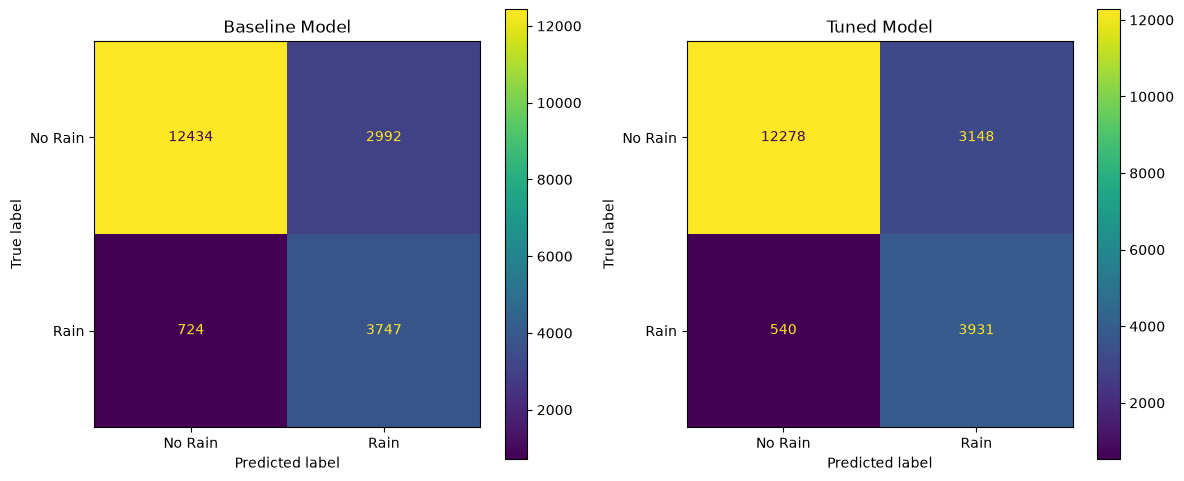

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, baseline_pred),
    display_labels=["No Rain", "Rain"]
).plot(ax=axes[0], values_format="d")

axes[0].set_title("Baseline Model")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, tuned_pred),
    display_labels=["No Rain", "Rain"]
).plot(ax=axes[1], values_format="d")

axes[1].set_title("Tuned Model")

plt.tight_layout()
plt.show()

## 7. Classification Metrics Comparison

Compare the models using threshold-based metrics at a classification threshold of 0.5.

In [20]:
metrics_comparison = pd.DataFrame({
    "Model": ["Baseline", "Tuned"],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, tuned_pred),
    ],
    "Precision": [
        precision_score(y_test, baseline_pred),
        precision_score(y_test, tuned_pred),
    ],
    "Recall": [
        recall_score(y_test, baseline_pred),
        recall_score(y_test, tuned_pred),
    ],
    "F1-Score": [
        f1_score(y_test, baseline_pred),
        f1_score(y_test, tuned_pred),
    ],
})

metrics_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Baseline,0.813238,0.556017,0.838068,0.668510
1,Tuned,0.814645,0.555304,0.879222,0.680693


## 8. Feature Importance

Inspect the feature importance of the tuned LightGBM model to identify which features contribute most to the final predictions.

In [21]:
feature_importance = pd.DataFrame({
    "Feature": tuned_model.feature_name_,
    "Importance": tuned_model.feature_importances_,
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(20)

,Feature,Importance
0,PressureDiff,2842
1,Pressure3pm,2317
2,TempRange,2288
3,TempChange,2242
4,TempHumidityInteraction,2178
5,Sunshine,2172
6,HumidityDiff,2020
7,MinTemp,1991
8,WindGustSpeed,1944
9,Evaporation,1885


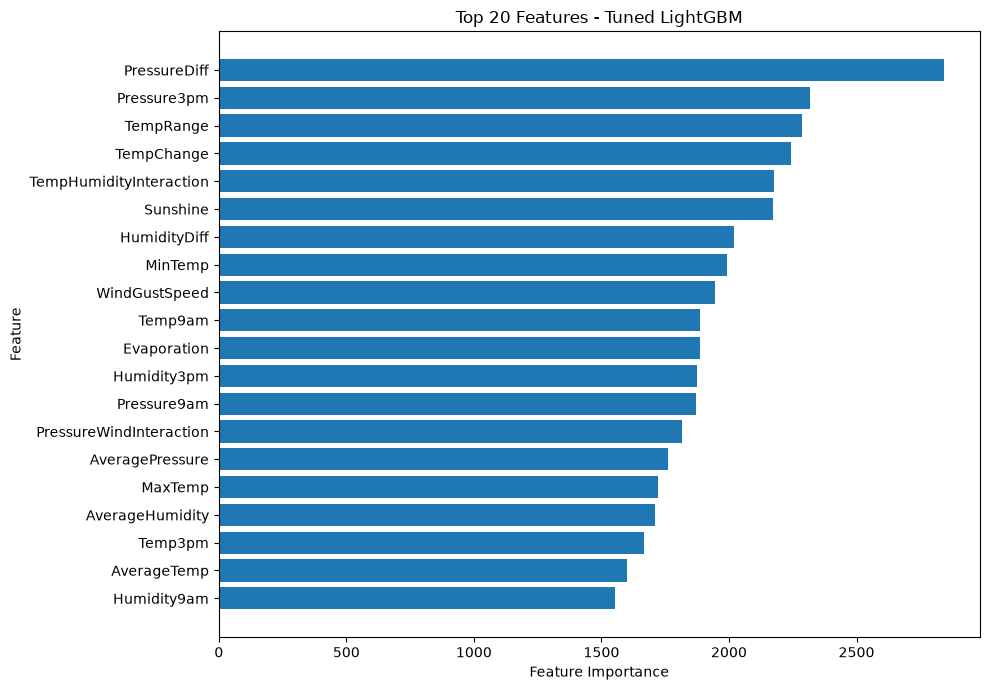

In [22]:
top_features = feature_importance.head(20).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features - Tuned LightGBM")

plt.tight_layout()
plt.show()

## 9. Model Comparison

Compare the baseline and tuned models using their test-set performance and training characteristics.

In [23]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Tuned"],
    "PR-AUC": [baseline_pr_auc, tuned_pr_auc],
    "ROC-AUC": [baseline_roc_auc, tuned_roc_auc],
    "Best Iteration": [
        baseline_model.best_iteration_,
        tuned_model.best_iteration_,
    ],
    "Non-zero Features": [
        (baseline_model.feature_importances_ > 0).sum(),
        (tuned_model.feature_importances_ > 0).sum(),
    ],
})

comparison

,Model,PR-AUC,ROC-AUC,Best Iteration,Non-zero Features
0,Baseline,0.779255,0.908311,302,124
1,Tuned,0.807236,0.922616,730,126


## 10. Final Model Selection

The tuned model is selected as the final model if it provides better performance on the held-out test set than the baseline model.

The test set is used only for final evaluation and was not used during Optuna hyperparameter optimization.

In [24]:
if tuned_pr_auc > baseline_pr_auc and tuned_roc_auc > baseline_roc_auc:
    selected_model = "Tuned LightGBM"
else:
    selected_model = "Baseline LightGBM"

print(f"Selected model: {selected_model}")

Selected model: Tuned LightGBM


## 11. Evaluation Conclusion

The baseline and tuned LightGBM models were evaluated on the held-out test set.

The tuned model achieved higher PR-AUC and ROC-AUC than the baseline model, indicating improved ranking performance after hyperparameter optimization with Optuna.

The tuned model is therefore selected as the final candidate for the deployment phase.